# INM707 Deep Reinforcement Learning — QTrade Agent
**City, University of London** | Tasks 1–8

---

Run cells **top to bottom**. Google Drive mounts once at the top — Q-tables and DQN weights save permanently so you never retrain unless you delete them from Drive.

## Setup — Run This First Every Session

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import random, os
from collections import deque
import yfinance as yf
from torch.distributions import Categorical
import gymnasium as gym

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Reproducibility — fix all random seeds for deterministic results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

SAVE_DIR = '/content/drive/MyDrive/DRL_CW'
os.makedirs(SAVE_DIR, exist_ok=True)
Q_PATH   = os.path.join(SAVE_DIR, 'q_table_base.npy')
DQN_PATH = os.path.join(SAVE_DIR, 'dqn_weights.pth')

print(f'Drive mounted. Saving to: {SAVE_DIR}')
print(f'Files on Drive: {os.listdir(SAVE_DIR)}')

Mounted at /content/drive
Drive mounted. Saving to: /content/drive/MyDrive/DRL_CW
Files on Drive: ['q_table_base.npy', 'q_rewards_eg.npy', 'q_rewards_softmax.npy', 'dqn_rewards_collapsed.npy', 'q_rewards.npy', 'fig13_collapsed.png', 'fig13_ql_vs_dqn.png', 'ppo_cartpole_sb3_rewards.npy', 'ppo_weights.pth', 'ppo_rewards.npy', 'fig14_algorithm_comparison.png', 'ppo_cartpole_weights.pth', 'ppo_cartpole_custom_rewards.npy', 'fig15_cartpole_validation.png', 'fig1_msft.png', 'DRL_QTrade_Clean.ipynb', 'fig4_epsilon_decay.png', 'fig1_msft_price.png', 'fig2_reward_matrix.png', 'fig3_transition.png', 'fig5_reward_base.png', 'fig6_alpha.png', 'fig7_gamma.png', 'fig8_decay.png', 'fig9_policy.png', 'fig11_agent_test.png', 'fig10_all_experiments.png', 'dqn_rewards_fixed.npy', 'fig12_dqn_reward.png', 'dqn_ablation_Vanilla_DQN.npy', 'dqn_ablation_Double_DQN_only.npy', 'dqn_ablation_Dueling_DQN_only.npy', 'dqn_weights.pth', 'dqn_ablation_Double_plus_Dueling.npy', 'fig12b_dqn_ablation.png']


---
## Task 1: Define the Environment

In [2]:
df = yf.download('MSFT', start='2018-01-01', end='2023-12-31', progress=False)
df = df[['Close']].copy()
df.columns = ['Close']
df['price_change'] = df['Close'].diff()
df = df.dropna().reset_index()
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
print(f'Data loaded: {len(df)} trading days')
print(df.head())

/tmp/ipykernel_2000/1562592983.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('MSFT', start='2018-01-01', end='2023-12-31', progress=False)


Data loaded: 1508 trading days
        Date      Close  price_change
0 2018-01-03  79.237404      0.367050
1 2018-01-04  79.934830      0.697426
2 2018-01-05  80.925880      0.991051
3 2018-01-08  81.008476      0.082596
4 2018-01-09  80.953369     -0.055107


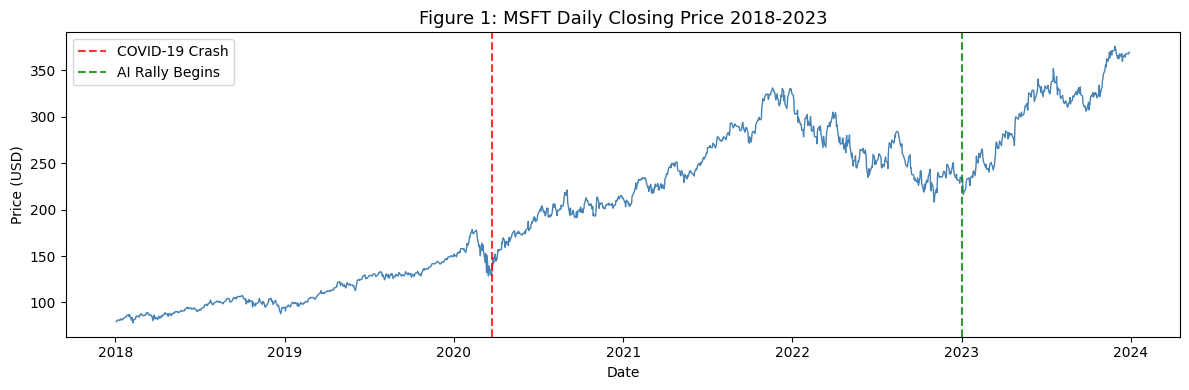

Figure 1 saved


In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['Date'], df['Close'], color='steelblue', linewidth=1)
ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle='--', alpha=0.8, label='COVID-19 Crash')
ax.axvline(pd.Timestamp('2023-01-01'), color='green', linestyle='--', alpha=0.8, label='AI Rally Begins')
ax.set_title('Figure 1: MSFT Daily Closing Price 2018-2023', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig1_msft_price.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

---
## Task 2: State Transition Function and Reward Function

In [4]:
# State definitions — Table II from the report
# s0: price_change >= 0, holding=1  ->  price up,   holding     ->  valid: HOLD, SELL
# s1: price_change >= 0, holding=0  ->  price up,   not holding ->  valid: HOLD, BUY
# s2: price_change <  0, holding=1  ->  price down, holding     ->  valid: HOLD, SELL
# s3: price_change <  0, holding=0  ->  price down, not holding ->  valid: HOLD, BUY

S = ['s0','s1','s2','s3']
A = ['hold','buy','sell']    # action indices: 0=hold  1=buy  2=sell

def get_state(price_change, holding):
    if price_change >= 0 and holding == 1: return 0  # s0
    if price_change >= 0 and holding == 0: return 1  # s1
    if price_change <  0 and holding == 1: return 2  # s2
    if price_change <  0 and holding == 0: return 3  # s3

print('States:', S)
print('Actions:', A)
print()
print('s0: price up,   holding     -> HOLD or SELL')
print('s1: price up,   not holding -> HOLD or BUY')
print('s2: price down, holding     -> HOLD or SELL')
print('s3: price down, not holding -> HOLD or BUY')

States: ['s0', 's1', 's2', 's3']
Actions: ['hold', 'buy', 'sell']

s0: price up,   holding     -> HOLD or SELL
s1: price up,   not holding -> HOLD or BUY
s2: price down, holding     -> HOLD or SELL
s3: price down, not holding -> HOLD or BUY


In [5]:
# Reward matrix — derived from average daily price changes in the dataset
up_days   = df[df['price_change'] >= 0]['price_change']
down_days = df[df['price_change'] <  0]['price_change']
avg_up    = up_days.mean()
avg_down  = down_days.mean()

print(f'Average price change on up days:   {avg_up:.4f}')
print(f'Average price change on down days: {avg_down:.4f}')

# R[state, action]:  columns = [hold, buy, sell]
R = np.full((4, 3), np.nan)
R[0] = [round(avg_up/10, 4),  np.nan,          round(avg_up, 4)   ]  # s0: hold(small reward), sell
R[1] = [0.0,                   0.0,             np.nan             ]  # s1: hold(neutral),  buy(neutral - dont chase)
R[2] = [round(avg_down/10, 4), np.nan,          round(avg_down, 4) ]  # s2: hold(penalty),  sell
R[3] = [0.0,                   round(avg_up, 4), np.nan            ]  # s3: hold(neutral),  buy(rewarded - buy the dip)

R_df = pd.DataFrame(R, index=S, columns=A)
print()
print('Reward Matrix R[state, action]:')
print(R_df.to_string())

Average price change on up days:   2.6729
Average price change on down days: -2.7709

Reward Matrix R[state, action]:
      hold     buy    sell
s0  0.2673     NaN  2.6729
s1  0.0000  0.0000     NaN
s2 -0.2771     NaN -2.7709
s3  0.0000  2.6729     NaN


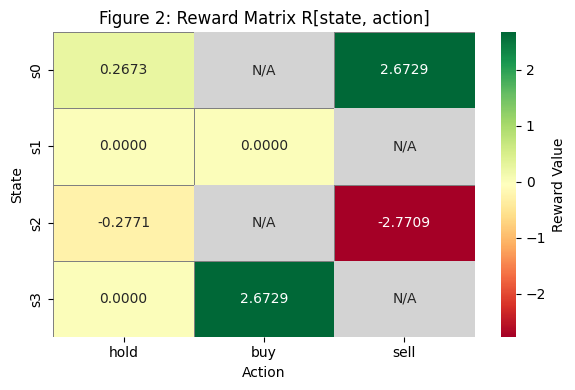

Figure 2 saved


In [6]:
# Figure 2: Reward Matrix Heatmap
R_display = R_df.copy().astype(object)
for i in range(4):
    for j in range(3):
        R_display.iloc[i,j] = 'N/A' if np.isnan(R[i,j]) else f'{R[i,j]:.4f}'
mask = np.isnan(R)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(R, annot=R_display, fmt='', mask=mask, cmap='RdYlGn',
            linewidths=0.5, linecolor='grey', cbar_kws={'label':'Reward Value'},
            xticklabels=A, yticklabels=S, ax=ax)
sns.heatmap(np.where(mask, 0, np.nan), cmap=['#d3d3d3'],
            annot=pd.DataFrame([['N/A' if mask[i,j] else '' for j in range(3)]
                                 for i in range(4)], index=S, columns=A),
            fmt='', cbar=False, xticklabels=A, yticklabels=S, ax=ax)
ax.set_title('Figure 2: Reward Matrix R[state, action]', fontsize=12)
ax.set_xlabel('Action'); ax.set_ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig2_reward_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

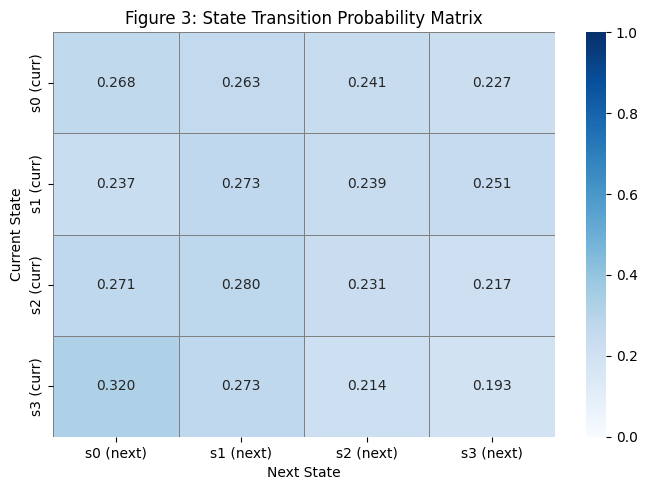

Figure 3 saved


In [7]:
# Figure 3: State Transition Probability Matrix (computed with random policy)
trans_count = np.zeros((4, 4))
holding = 0
for i in range(len(df) - 1):
    pc_today    = df.loc[i,   'price_change']
    pc_tomorrow = df.loc[i+1, 'price_change']
    curr   = get_state(pc_today, holding)
    action = np.random.choice([0,2] if holding==1 else [0,1])
    if action==1: holding=1
    elif action==2: holding=0
    nxt = get_state(pc_tomorrow, holding)
    trans_count[curr, nxt] += 1

row_sums = trans_count.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1
trans_prob = trans_count / row_sums

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(trans_prob, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, linecolor='grey',
            xticklabels=[f'{s} (next)' for s in S],
            yticklabels=[f'{s} (curr)' for s in S],
            vmin=0, vmax=1, ax=ax)
ax.set_title('Figure 3: State Transition Probability Matrix', fontsize=12)
ax.set_xlabel('Next State'); ax.set_ylabel('Current State')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig3_transition.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')

---
## Task 3: Q-Learning Parameters and Exploration Policies

In [8]:
alpha         = 0.5    # learning rate
gamma         = 0.9    # discount factor
epsilon       = 0.9    # initial exploration rate
epsilon_decay = 0.995  # decay per episode
epsilon_min   = 0.01   # minimum exploration floor
episodes      = 2000
episode_data  = df.tail(300).reset_index(drop=True)  # last 300 days per episode

print(f'alpha (learning rate) : {alpha}')
print(f'gamma (discount)      : {gamma}')
print(f'epsilon (start)       : {epsilon}')
print(f'epsilon decay         : {epsilon_decay}')
print(f'epsilon min           : {epsilon_min}')
print(f'episodes              : {episodes}')
print(f'timesteps per episode : {len(episode_data)}')

alpha (learning rate) : 0.5
gamma (discount)      : 0.9
epsilon (start)       : 0.9
epsilon decay         : 0.995
epsilon min           : 0.01
episodes              : 2000
timesteps per episode : 300


In [9]:
def epsilon_greedy_masked(Q, state, eps, holding):
    """epsilon-greedy with action masking — only valid actions are selected."""
    valid = [0,2] if holding==1 else [0,1]   # hold+sell OR hold+buy
    if np.random.rand() < eps:
        return np.random.choice(valid)
    q_masked = Q[state].copy()
    for a in range(3):
        if a not in valid: q_masked[a] = -np.inf
    return int(np.argmax(q_masked))

def softmax_masked(Q, state, holding, temperature=1.0):
    """Softmax policy with action masking."""
    valid  = [0,2] if holding==1 else [0,1]
    q_vals = np.array([Q[state,a] for a in valid])
    q_vals = q_vals - np.max(q_vals)   # numerical stability
    exp_q  = np.exp(q_vals / temperature)
    probs  = exp_q / exp_q.sum()
    return valid[np.random.choice(len(valid), p=probs)]

print('Exploration policies defined')

Exploration policies defined


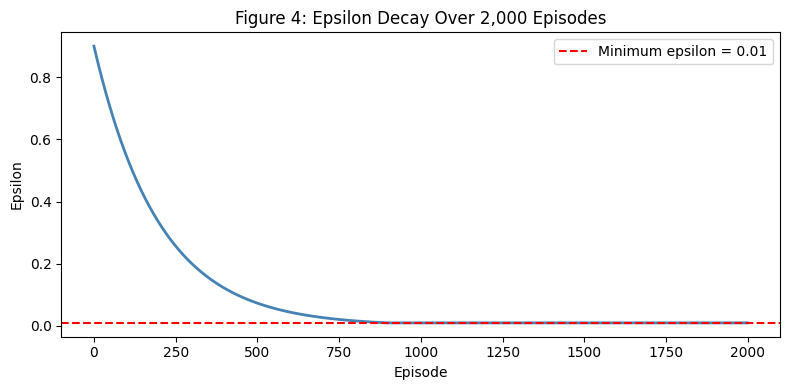

Figure 4 saved


In [10]:
# Figure 4: Epsilon Decay
eps_vals = []
eps_plot = epsilon
for _ in range(episodes):
    eps_vals.append(eps_plot)
    if eps_plot > epsilon_min: eps_plot *= epsilon_decay

plt.figure(figsize=(8, 4))
plt.plot(eps_vals, color='steelblue', linewidth=2)
plt.axhline(epsilon_min, color='red', linestyle='--', linewidth=1.5,
            label=f'Minimum epsilon = {epsilon_min}')
plt.title('Figure 4: Epsilon Decay Over 2,000 Episodes', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Epsilon')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig4_epsilon_decay.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

---
## Task 4: Run Q-Learning and Represent Performance

In [11]:
def train_qlearning(data, alpha=0.5, gamma=0.9,
                    eps_start=0.9, eps_decay=0.995, eps_min=0.01,
                    n_episodes=2000, policy='epsilon-greedy', temperature=1.0):
    """
    General Q-learning training loop used for all experiments.
    action masking is applied via epsilon_greedy_masked / softmax_masked.
    """
    Q   = np.zeros((4, 3))
    eps = eps_start
    episode_rewards = []

    for ep in range(n_episodes):
        holding = np.random.randint(0, 2)   # random initial holding
        total   = 0.0

        for t in range(len(data) - 1):
            pc    = float(data.loc[t, 'price_change'])
            state = get_state(pc, holding)

            if policy == 'softmax':
                action = softmax_masked(Q, state, holding, temperature)
            else:
                action = epsilon_greedy_masked(Q, state, eps, holding)

            # Execute action
            if action==1 and holding==0: holding=1     # buy
            elif action==2 and holding==1: holding=0   # sell

            reward = R[state, action]
            if np.isnan(reward): reward = 0.0
            total += reward

            next_pc    = float(data.loc[t+1, 'price_change'])
            next_state = get_state(next_pc, holding)
            best_next  = np.nanmax(Q[next_state])

            # Q-update rule
            Q[state, action] += alpha * (reward + gamma*best_next - Q[state, action])

        if eps > eps_min: eps *= eps_decay
        episode_rewards.append(total)

    return Q, episode_rewards

def smooth(values, window=50):
    return np.convolve(values, np.ones(window)/window, mode='valid')

print('Training function defined')

Training function defined


In [12]:
# Train base agent or load from Drive
if os.path.exists(Q_PATH):
    Q = np.load(Q_PATH)
    print('Q-table loaded from Drive. Running episode pass for reward history...')
    _, episode_rewards = train_qlearning(episode_data)
    Q = np.load(Q_PATH)   # keep the saved converged table
else:
    print('Training base Q-learning agent (2000 episodes)...')
    Q, episode_rewards = train_qlearning(episode_data)
    np.save(Q_PATH, Q)
    print('Training complete. Q-table saved to Drive.')

print()
print('Final Q-Table:')
print(pd.DataFrame(np.round(Q, 4), index=S, columns=A))

# Valid actions per state (for correct policy readout)
valid_map = {0:[0,2], 1:[0,1], 2:[0,2], 3:[0,1]}
print()
print('Converged Policy:')
print('-'*35)
for i, s in enumerate(S):
    v    = valid_map[i]
    best = v[int(np.argmax([Q[i,a] for a in v]))]
    print(f'  {s}: {A[best].upper()}')

Q-table loaded from Drive. Running episode pass for reward history...

Final Q-Table:
       hold      buy     sell
s0  11.3663   0.0000  15.4306
s1   8.7155  13.2013   0.0000
s2  14.0729   0.0000   7.5316
s3  12.0959  16.9186   0.0000

Converged Policy:
-----------------------------------
  s0: SELL
  s1: BUY
  s2: HOLD
  s3: BUY


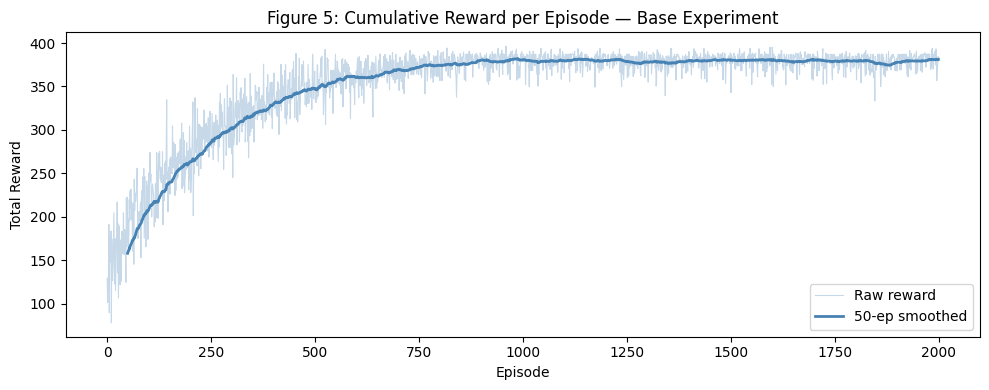

Figure 5 saved


In [13]:
# Figure 5: Cumulative Reward per Episode — Base Experiment
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', linewidth=0.8, label='Raw reward')
plt.plot(np.arange(49, len(episode_rewards)), smooth(episode_rewards),
         color='steelblue', linewidth=2, label='50-ep smoothed')
plt.title('Figure 5: Cumulative Reward per Episode — Base Experiment', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Total Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig5_reward_base.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

---
## Task 5: Repeat with Different Parameter Values and Policies

alpha=0.2  last-100 avg: 381.46
alpha=0.5  last-100 avg: 378.13
alpha=0.9  last-100 avg: 366.73


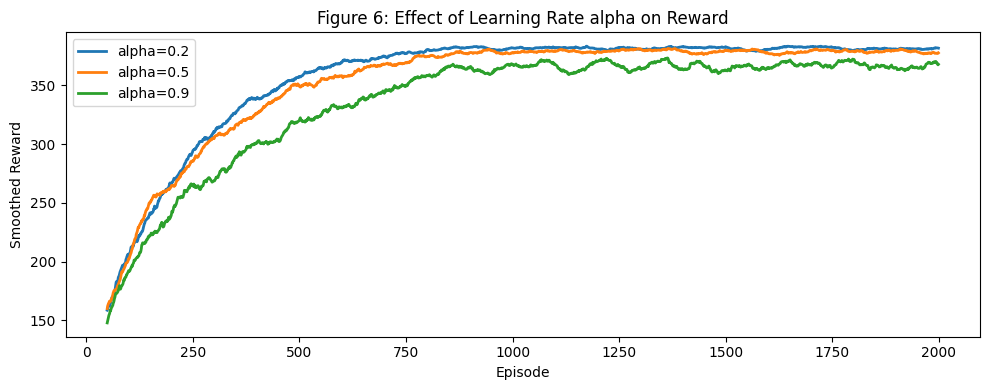

Figure 6 saved


In [14]:
# Alpha sensitivity: alpha in {0.2, 0.5, 0.9}, gamma=0.9 fixed
alpha_results = {}
for a in [0.2, 0.5, 0.9]:
    _, rewards = train_qlearning(episode_data, alpha=a)
    alpha_results[a] = rewards
    print(f'alpha={a}  last-100 avg: {np.mean(rewards[-100:]):.2f}')

plt.figure(figsize=(10, 4))
for a, rewards in alpha_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=f'alpha={a}', linewidth=2)
plt.title('Figure 6: Effect of Learning Rate alpha on Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig6_alpha.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved')

gamma=0.2  last-100 avg: 380.76
gamma=0.5  last-100 avg: 381.85
gamma=0.9  last-100 avg: 379.11


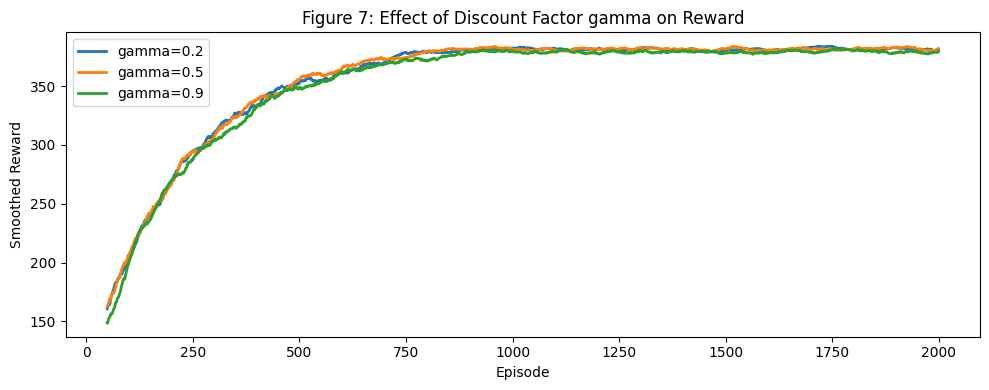

Figure 7 saved


In [15]:
# Gamma sensitivity: gamma in {0.2, 0.5, 0.9}, alpha=0.5 fixed
gamma_results = {}
for g in [0.2, 0.5, 0.9]:
    _, rewards = train_qlearning(episode_data, gamma=g)
    gamma_results[g] = rewards
    print(f'gamma={g}  last-100 avg: {np.mean(rewards[-100:]):.2f}')

plt.figure(figsize=(10, 4))
for g, rewards in gamma_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=f'gamma={g}', linewidth=2)
plt.title('Figure 7: Effect of Discount Factor gamma on Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig7_gamma.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved')

decay=0.99  last-100 avg: 378.77
decay=0.995  last-100 avg: 378.59
decay=0.999  last-100 avg: 332.15


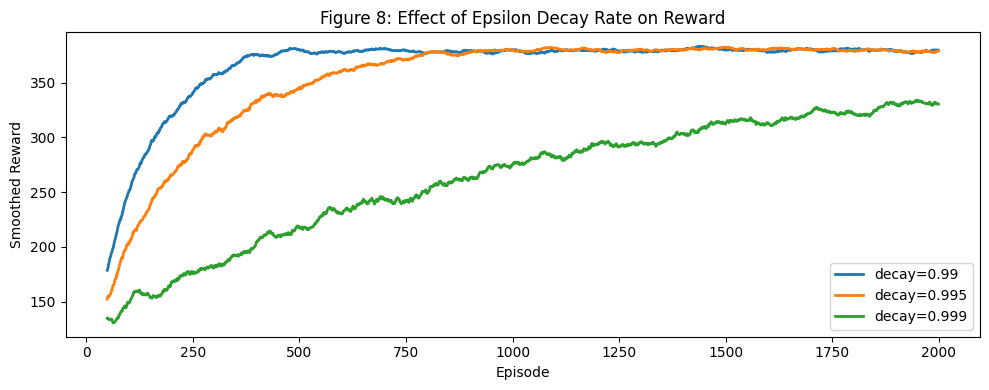

Figure 8 saved


In [16]:
# Epsilon decay sensitivity: decay in {0.99, 0.995, 0.999}
decay_results = {}
for d in [0.99, 0.995, 0.999]:
    _, rewards = train_qlearning(episode_data, eps_decay=d)
    decay_results[d] = rewards
    print(f'decay={d}  last-100 avg: {np.mean(rewards[-100:]):.2f}')

plt.figure(figsize=(10, 4))
for d, rewards in decay_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=f'decay={d}', linewidth=2)
plt.title('Figure 8: Effect of Epsilon Decay Rate on Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig8_decay.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved')

epsilon-greedy last-100 avg: 378.68
softmax        last-100 avg: 376.12


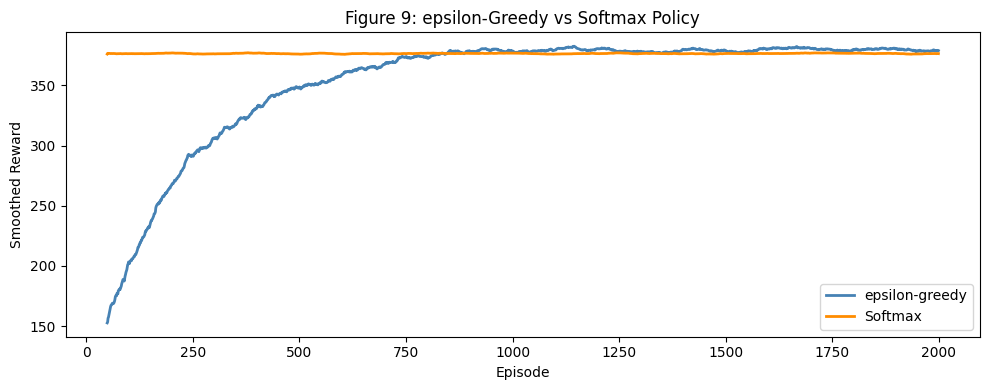

Figure 9 saved


In [17]:
# Policy comparison: epsilon-greedy vs softmax
_, rewards_eg = train_qlearning(episode_data, policy='epsilon-greedy')
_, rewards_sm = train_qlearning(episode_data, policy='softmax')
print(f'epsilon-greedy last-100 avg: {np.mean(rewards_eg[-100:]):.2f}')
print(f'softmax        last-100 avg: {np.mean(rewards_sm[-100:]):.2f}')

plt.figure(figsize=(10, 4))
plt.plot(np.arange(49, len(rewards_eg)), smooth(rewards_eg),
         label='epsilon-greedy', color='steelblue', linewidth=2)
plt.plot(np.arange(49, len(rewards_sm)), smooth(rewards_sm),
         label='Softmax', color='darkorange', linewidth=2)
plt.title('Figure 9: epsilon-Greedy vs Softmax Policy', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig9_policy.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved')

---
## Task 6: Quantitative and Qualitative Analysis

In [18]:
all_results = {
    'Base (a=0.5, g=0.9)' : episode_rewards,
    'a=0.2'               : alpha_results[0.2],
    'a=0.9'               : alpha_results[0.9],
    'g=0.2'               : gamma_results[0.2],
    'g=0.5'               : gamma_results[0.5],
    'decay=0.99'          : decay_results[0.99],
    'decay=0.999'         : decay_results[0.999],
    'Softmax'             : rewards_sm,
}

sm_base   = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
base_conv = np.mean(sm_base[-50:])
conv_ep   = next((i for i,r in enumerate(sm_base) if r >= 0.95*base_conv), None)

print(f'{"Experiment":<22} {"First100":>10} {"Last100":>10} {"Peak":>10} {"Improv%":>10}')
print('-'*65)
for name, rewards in all_results.items():
    first  = np.mean(rewards[:100])
    last   = np.mean(rewards[-100:])
    peak   = np.max(rewards)
    improv = ((last-first)/abs(first))*100 if first!=0 else 0
    print(f'{name:<22}  {first:>9.2f}  {last:>9.2f}  {peak:>9.2f}  {improv:>9.1f}%')
print(f'\nBase convergence: ~episode {conv_ep}')

Experiment               First100    Last100       Peak    Improv%
-----------------------------------------------------------------
Base (a=0.5, g=0.9)        181.84     378.30     396.81      108.0%
a=0.2                      181.84     381.46     396.54      109.8%
a=0.9                      170.09     366.73     398.90      115.6%
g=0.2                      180.92     380.76     402.72      110.5%
g=0.5                      183.96     381.85     401.98      107.6%
decay=0.99                 214.08     378.77     399.04       76.9%
decay=0.999                141.93     332.15     374.94      134.0%
Softmax                    376.07     376.12     377.85        0.0%

Base convergence: ~episode 517


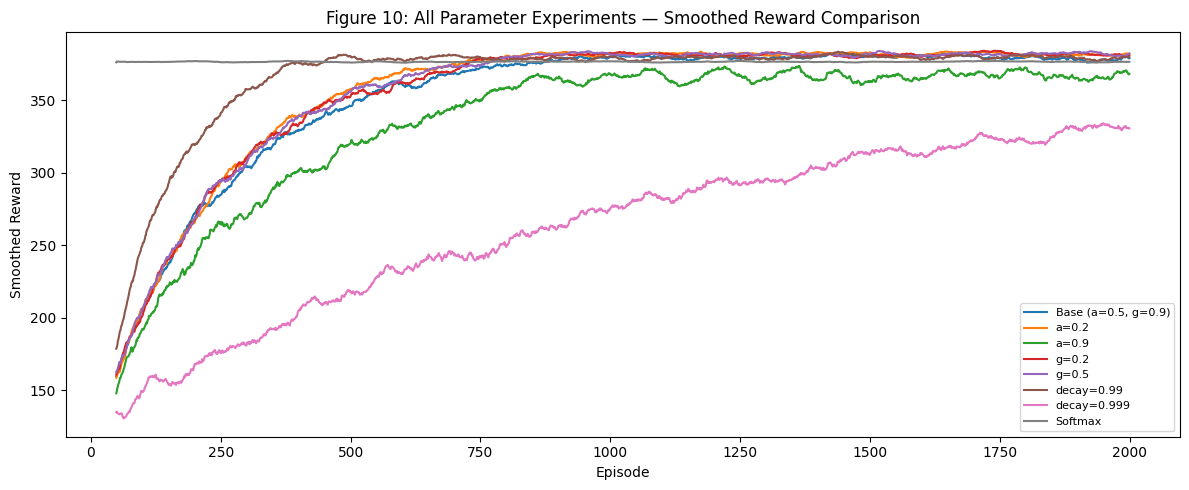

Figure 10 saved


In [19]:
# Figure 10: All experiments on one chart
plt.figure(figsize=(12, 5))
for name, rewards in all_results.items():
    plt.plot(np.arange(49, len(rewards)), smooth(rewards), label=name, linewidth=1.5)
plt.title('Figure 10: All Parameter Experiments — Smoothed Reward Comparison', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Smoothed Reward')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig10_all_experiments.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved')

### Agent Visualisation on Test Data

In [20]:
# Test data = all data before the last-300-day training window
test_df = df.iloc[:-300].reset_index(drop=True)
print(f'Test period: {test_df["Date"].iloc[0].date()} to {test_df["Date"].iloc[-1].date()} ({len(test_df)} days)')

initial_balance = 10000.0
balance  = initial_balance
holding  = 0
records  = []
valid_map = {0:[0,2], 1:[0,1], 2:[0,2], 3:[0,1]}

for i in range(len(test_df) - 1):
    pc     = float(test_df.loc[i, 'price_change'])
    price  = float(test_df.loc[i, 'Close'])
    date   = test_df.loc[i, 'Date']
    state  = get_state(pc, holding)
    valid  = valid_map[state]
    action = valid[int(np.argmax([Q[state,a] for a in valid]))]
    aname  = A[action]
    if action==1 and holding==0: holding=1;  balance -= price
    elif action==2 and holding==1: holding=0; balance += price
    portfolio = balance + (price if holding==1 else 0)
    records.append({'date':date, 'price':price, 'action':aname, 'portfolio':round(portfolio,2)})

results_df = pd.DataFrame(records)
total_ret  = results_df['portfolio'].iloc[-1] - initial_balance
print(f'Initial: {initial_balance:,.2f}')
print(f'Final:   {results_df["portfolio"].iloc[-1]:,.2f}')
print(f'Return:  {total_ret:,.2f} ({total_ret/initial_balance*100:.1f}%)')
print(f'Buys: {(results_df["action"]=="buy").sum()}  |  Sells: {(results_df["action"]=="sell").sum()}  |  Holds: {(results_df["action"]=="hold").sum()}')

Test period: 2018-01-03 to 2022-10-19 (1208 days)
Initial: 10,000.00
Final:   10,140.33
Return:  140.33 (1.4%)
Buys: 432  |  Sells: 431  |  Holds: 344


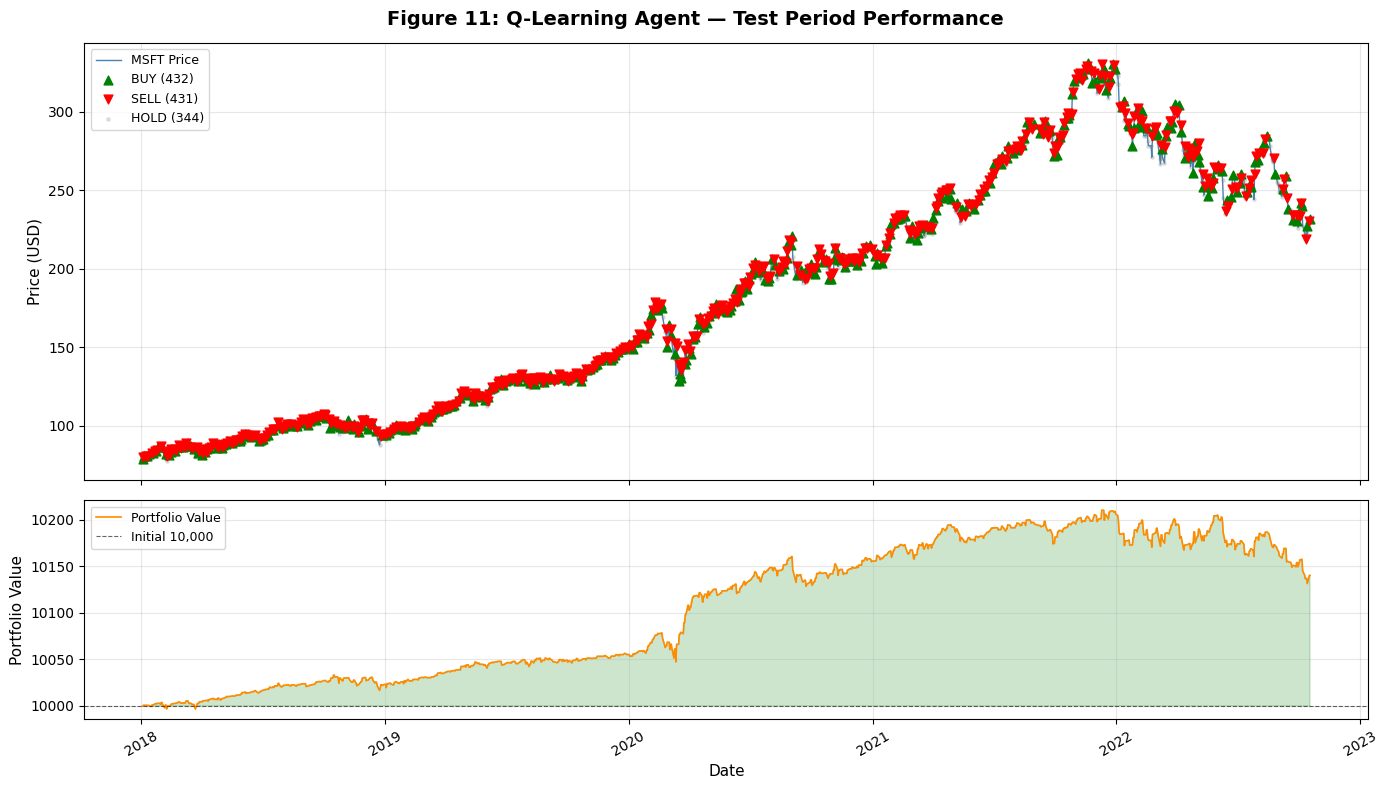

Figure 11 saved


In [21]:
# Figure 11: Price chart with trade markers and portfolio value
buys  = results_df[results_df['action']=='buy']
sells = results_df[results_df['action']=='sell']
holds = results_df[results_df['action']=='hold']

fig,(ax1,ax2) = plt.subplots(2,1,figsize=(14,8),sharex=True,
                              gridspec_kw={'height_ratios':[2,1]})
fig.suptitle('Figure 11: Q-Learning Agent — Test Period Performance',
             fontsize=14, fontweight='bold')

ax1.plot(results_df['date'], results_df['price'],
         color='steelblue', linewidth=1, label='MSFT Price', zorder=1)
ax1.scatter(buys['date'],  buys['price'],  marker='^', color='green',
            s=40, zorder=3, label=f'BUY ({len(buys)})')
ax1.scatter(sells['date'], sells['price'], marker='v', color='red',
            s=40, zorder=3, label=f'SELL ({len(sells)})')
ax1.scatter(holds['date'], holds['price'], marker='o', color='grey',
            s=6,  zorder=2, alpha=0.2, label=f'HOLD ({len(holds)})')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(results_df['date'], results_df['portfolio'],
         color='darkorange', linewidth=1.2, label='Portfolio Value')
ax2.axhline(initial_balance, color='black', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Initial {initial_balance:,.0f}')
ax2.fill_between(results_df['date'], results_df['portfolio'], initial_balance,
                 where=results_df['portfolio']>=initial_balance,
                 alpha=0.2, color='green')
ax2.fill_between(results_df['date'], results_df['portfolio'], initial_balance,
                 where=results_df['portfolio']<initial_balance,
                 alpha=0.2, color='red')
ax2.set_ylabel('Portfolio Value', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig11_agent_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved')

---
## Task 7: DQN with Two Improvements

**Improvement 1 — Dueling Architecture:** Separates the Q-value into state value V(s) and action advantage A(s,a), so the network learns which states are inherently good independently of which action is taken.

**Improvement 2 — Double DQN:** The online network selects the best next action, the target network evaluates it. This removes the maximisation bias present in vanilla DQN where the same network both selects and evaluates, causing systematic overestimation.

In [14]:
class ReplayMemory:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))
    def sample(self, n):
        return random.sample(self.buffer, n)
    def __len__(self):
        return len(self.buffer)

class DuelingDQN(nn.Module):
    """
    Dueling DQN architecture.
    Q(s,a) = V(s) + A(s,a) - mean(A(s,a))
    The mean subtraction forces identifiability between V and A.
    """
    def __init__(self, input_dim=2, output_dim=3):
        super().__init__()
        self.feature = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU())
        self.value   = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
        self.adv     = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, output_dim))

    def forward(self, x):
        f = self.feature(x)
        V = self.value(f)
        A = self.adv(f)
        return V + A - A.mean(dim=1, keepdim=True)

class DQNAgent:
    def __init__(self, state_dim=2, action_dim=3, lr=3e-4, gamma=0.9,
                 epsilon=0.9, epsilon_decay=0.997, epsilon_min=0.05,
                 batch_size=128, target_update=200, replay_capacity=20000,
                 grad_clip=10.0):
        self.action_dim    = action_dim
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.batch_size    = batch_size
        self.target_update = target_update
        self.grad_clip     = grad_clip
        self.steps         = 0
        # Online + target networks (Double DQN)
        self.online_net = DuelingDQN(state_dim, action_dim)
        self.target_net = DuelingDQN(state_dim, action_dim)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory    = ReplayMemory(capacity=replay_capacity)

    def select_action(self, sv, holding):
        valid = [0,2] if holding==1 else [0,1]
        if random.random() < self.epsilon:
            return random.choice(valid)
        st = torch.FloatTensor(sv).unsqueeze(0)
        with torch.no_grad():
            q = self.online_net(st).squeeze()
        masked = torch.full((self.action_dim,), float('-inf'))
        for a in valid:
            masked[a] = q[a]
        return int(torch.argmax(masked).item())

    def store(self, *args):
        self.memory.push(*args)

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        s, a, r, ns, d = zip(*self.memory.sample(self.batch_size))
        s  = torch.FloatTensor(s)
        a  = torch.LongTensor(a).unsqueeze(1)
        r  = torch.FloatTensor(r)
        ns = torch.FloatTensor(ns)
        d  = torch.FloatTensor(d)

        curr_q = self.online_net(s).gather(1, a).squeeze(1)

        with torch.no_grad():
            # Mask invalid next actions for Double DQN target selection.
            # ns[:,1] is holding flag in state vector.
            next_holding = (ns[:, 1] >= 0.5)
            next_q_online = self.online_net(ns)
            masked_next_q = next_q_online.clone()
            masked_next_q[next_holding, 1] = float('-inf')
            masked_next_q[~next_holding, 2] = float('-inf')

            best_a = masked_next_q.argmax(dim=1, keepdim=True)
            next_q_target = self.target_net(ns).gather(1, best_a).squeeze(1)
            target_q = r + self.gamma * next_q_target * (1 - d)

        loss = nn.SmoothL1Loss()(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), self.grad_clip)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def get_state_vector(price_change, holding):
    """Normalise price_change to ~[-1,1] range, combine with holding flag."""
    return [float(price_change) / 10.0, float(holding)]

print('DQN classes defined')

DQN classes defined


In [15]:
def run_dqn(agent, data, n_episodes, verbose=True):
    rewards       = []
    best_smoothed = -np.inf
    best_episode  = -1
    for ep in range(n_episodes):
        holding = random.randint(0, 1)
        total   = 0.0
        for t in range(len(data) - 1):
            pc     = float(data.loc[t, 'price_change'])
            sv     = get_state_vector(pc, holding)
            si     = get_state(pc, holding)            # state BEFORE action — for reward lookup
            action = agent.select_action(sv, holding)

            reward = R[si, action]                     # reward from pre-action state
            if np.isnan(reward): reward = 0.0
            total += reward

            # Now apply the action
            if action==1 and holding==0: holding=1
            elif action==2 and holding==1: holding=0

            next_pc = float(data.loc[t+1, 'price_change'])
            next_sv = get_state_vector(next_pc, holding)
            done    = 1.0 if t == len(data)-2 else 0.0
            agent.store(sv, action, reward, next_sv, done)
            agent.train_step()
        agent.decay_epsilon()
        rewards.append(total)

        # NEW: checkpoint if smoothed-50 hits new high
        if len(rewards) >= 50:
            sm = float(np.mean(rewards[-50:]))
            if sm > best_smoothed:
                best_smoothed = sm
                best_episode  = ep
                torch.save(agent.online_net.state_dict(), DQN_PATH)
        else:
            sm = float(np.mean(rewards))

        if verbose and ep % 50 == 0:
            print(f'  Ep {ep:>4} | Reward: {total:>8.2f} | Smoothed-50: {sm:>7.2f} | epsilon: {agent.epsilon:.4f}')

    # NEW: reload best weights into agent
    print(f'\nBest smoothed reward: {best_smoothed:.2f} at episode {best_episode}')
    agent.online_net.load_state_dict(torch.load(DQN_PATH))
    return rewards, best_smoothed, best_episode

# Train
if os.path.exists(DQN_PATH):
    print('Removing old weights — retraining with fixed code.')
    os.remove(DQN_PATH)

print(f'Training DQN (2000 episodes) with best-policy checkpointing...')
agent       = DQNAgent()
dqn_rewards, best_sm, best_ep = run_dqn(agent, episode_data, 2000, verbose=True)
np.save(os.path.join(SAVE_DIR, 'dqn_rewards_fixed.npy'), np.array(dqn_rewards))
print('Done. Reward history saved.')

Removing old weights — retraining with fixed code.
Training DQN (2000 episodes) with best-policy checkpointing...
  Ep    0 | Reward:   113.93 | Smoothed-50:  113.93 | epsilon: 0.8973
  Ep   50 | Reward:   189.19 | Smoothed-50:  152.44 | epsilon: 0.7721
  Ep  100 | Reward:   217.06 | Smoothed-50:  187.89 | epsilon: 0.6644
  Ep  150 | Reward:   209.72 | Smoothed-50:  213.27 | epsilon: 0.5718
  Ep  200 | Reward:   275.66 | Smoothed-50:  235.24 | epsilon: 0.4920
  Ep  250 | Reward:   277.25 | Smoothed-50:  262.03 | epsilon: 0.4234
  Ep  300 | Reward:   297.50 | Smoothed-50:  281.05 | epsilon: 0.3643
  Ep  350 | Reward:   300.85 | Smoothed-50:  296.47 | epsilon: 0.3135
  Ep  400 | Reward:   306.71 | Smoothed-50:  310.36 | epsilon: 0.2698
  Ep  450 | Reward:   334.43 | Smoothed-50:  323.25 | epsilon: 0.2321
  Ep  500 | Reward:   339.76 | Smoothed-50:  336.09 | epsilon: 0.1998
  Ep  550 | Reward:   351.74 | Smoothed-50:  344.82 | epsilon: 0.1719
  Ep  600 | Reward:   361.41 | Smoothed-50:  3

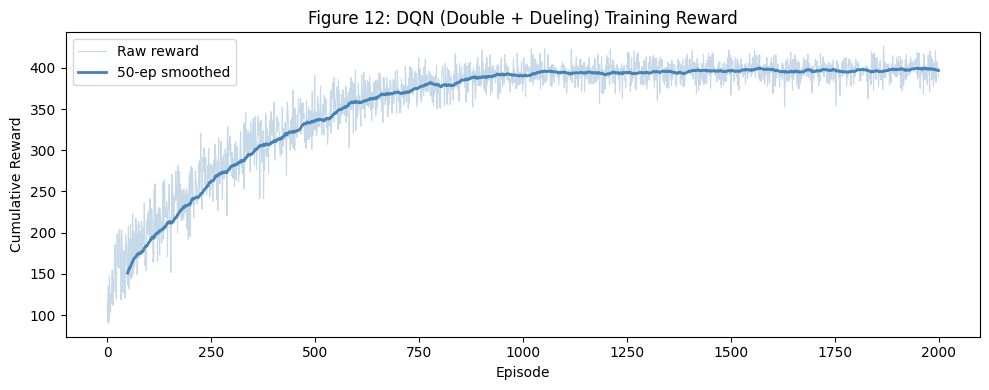

Figure 12 saved


In [16]:
# Figure 12: DQN Training Reward
plt.figure(figsize=(10, 4))
plt.plot(dqn_rewards, alpha=0.3, color='steelblue', linewidth=0.8, label='Raw reward')
if len(dqn_rewards) >= 50:
    plt.plot(np.arange(49, len(dqn_rewards)), smooth(dqn_rewards),
             color='steelblue', linewidth=2, label='50-ep smoothed')
plt.title('Figure 12: DQN (Double + Dueling) Training Reward', fontsize=12)
plt.xlabel('Episode'); plt.ylabel('Cumulative Reward')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig12_dqn_reward.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12 saved')

---
## Task 8: Quantitative and Qualitative Analysis of DQN Results

In [ ]:
def summarise(rewards, name):
    first  = np.mean(rewards[:100])
    last   = np.mean(rewards[-100:])
    peak   = np.max(rewards)
    peak_e = int(np.argmax(rewards))
    improv = ((last-first)/abs(first))*100 if first!=0 else 0
    sm     = np.convolve(rewards, np.ones(50)/50, mode='valid')
    conv   = next((i for i,r in enumerate(sm) if r >= 0.90*np.mean(sm[-50:])), None)
    print(f'--- {name} ---')
    print(f'  First-100 avg : {first:.2f}')
    print(f'  Last-100 avg  : {last:.2f}')
    print(f'  Peak reward   : {peak:.2f} (episode {peak_e})')
    print(f'  Convergence   : ~episode {conv}')
    print(f'  Improvement   : {improv:.1f}%')
    return dict(first=first, last=last, peak=peak, conv=conv, improv=improv)

ql_stats  = summarise(episode_rewards, 'Q-Learning (Base)')
print()
dqn_stats = summarise(dqn_rewards,     'DQN (Double + Dueling)')

--- Q-Learning (Base) ---
  First-100 avg : 184.37
  Last-100 avg  : 379.43
  Peak reward   : 399.27 (episode 493)
  Convergence   : ~episode 414
  Improvement   : 105.8%

--- DQN (Double + Dueling) ---
  First-100 avg : 164.93
  Last-100 avg  : 396.64
  Peak reward   : 421.52 (episode 1516)
  Convergence   : ~episode 601
  Improvement   : 140.5%


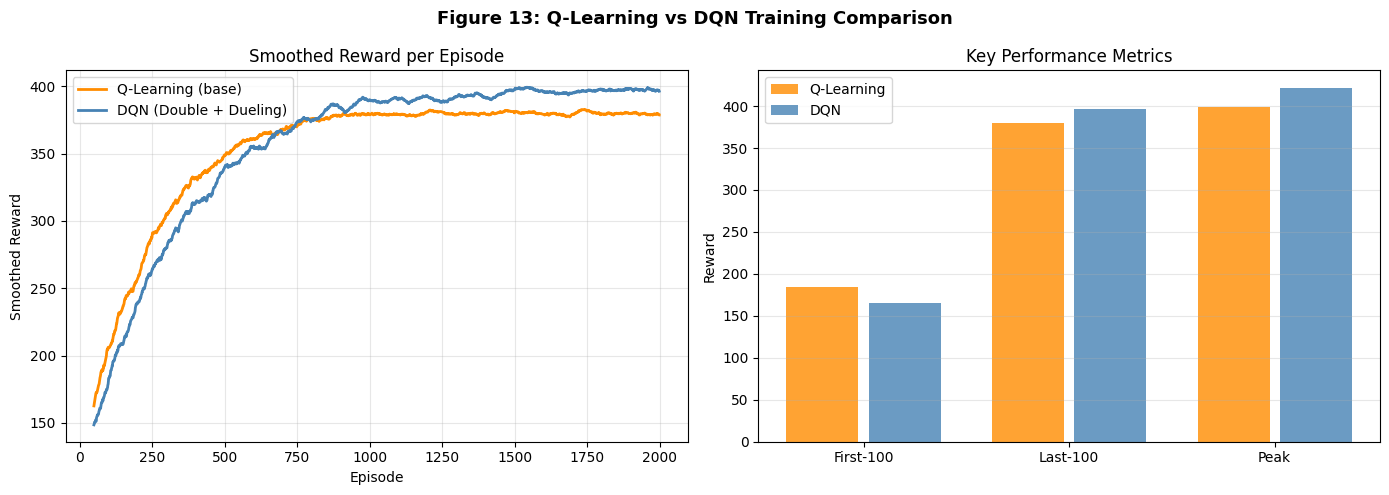

Figure 13 saved

All figures saved to: /content/drive/MyDrive/DRL_CW
Files: ['DRL_QTrade_Clean.ipynb', 'q_table_base.npy', 'fig4_epsilon_decay.png', 'fig1_msft_price.png', 'fig2_reward_matrix.png', 'fig3_transition.png', 'fig5_reward_base.png', 'fig6_alpha.png', 'fig7_gamma.png', 'fig8_decay.png', 'fig11_agent_test.png', 'fig9_policy.png', 'fig10_all_experiments.png', 'dqn_rewards_collapsed.npy', 'q_rewards.npy', 'q_rewards_eg.npy', 'q_rewards_softmax.npy', 'fig12_dqn_reward.png', 'fig13_ql_vs_dqn.png', 'ppo_weights.pth', 'ppo_rewards.npy', 'dqn_weights.pth', 'dqn_rewards_fixed.npy', 'fig13_collapsed.png']


In [ ]:
# Figure 13: Q-Learning vs DQN comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 13: Q-Learning vs DQN Training Comparison',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(np.arange(49, len(episode_rewards)), smooth(episode_rewards),
        color='darkorange', linewidth=2, label='Q-Learning (base)')
ax.plot(np.arange(49, len(dqn_rewards)), smooth(dqn_rewards),
        color='steelblue', linewidth=2, label='DQN (Double + Dueling)')
ax.set_title('Smoothed Reward per Episode')
ax.set_xlabel('Episode'); ax.set_ylabel('Smoothed Reward')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
metrics  = ['First-100', 'Last-100', 'Peak']
ql_vals  = [ql_stats['first'],  ql_stats['last'],  ql_stats['peak']]
dqn_vals = [dqn_stats['first'], dqn_stats['last'], dqn_stats['peak']]
x = np.arange(len(metrics))
ax2.bar(x-0.2, ql_vals,  0.35, label='Q-Learning', color='darkorange', alpha=0.8)
ax2.bar(x+0.2, dqn_vals, 0.35, label='DQN',        color='steelblue',  alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(metrics)
ax2.set_title('Key Performance Metrics')
ax2.set_ylabel('Reward')
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig13_ql_vs_dqn.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 13 saved')
print()
print(f'All figures saved to: {SAVE_DIR}')
print(f'Files: {os.listdir(SAVE_DIR)}')

In [ ]:
for f in os.listdir(SAVE_DIR):
       if 'dqn' in f.lower():
           print(f, os.path.getsize(os.path.join(SAVE_DIR, f)))

dqn_rewards_collapsed.npy 16128
fig12_dqn_reward.png 105302
fig13_ql_vs_dqn.png 106236
dqn_weights.pth 39365
dqn_rewards_fixed.npy 16128



Training Vanilla DQN (Double=False, Dueling=False)...

Best smoothed reward: 371.46 at episode 511
  last-100 avg: 4.19

Training Double DQN only (Double=True, Dueling=False)...

Best smoothed reward: 399.49 at episode 785
  last-100 avg: 156.99

Training Dueling DQN only (Double=False, Dueling=True)...

Best smoothed reward: 371.09 at episode 479
  last-100 avg: 92.30

Training Double + Dueling (Double=True, Dueling=True)...

Best smoothed reward: 387.98 at episode 659
  last-100 avg: 42.51

--- DQN Ablation Comparison ---
Configuration            First100    Last100       Peak
--------------------------------------------------------
Vanilla DQN                178.74       4.19     402.71
Double DQN only            179.09     156.99     416.24
Dueling DQN only           185.90      92.30     403.46
Double + Dueling           182.93      42.51     410.64


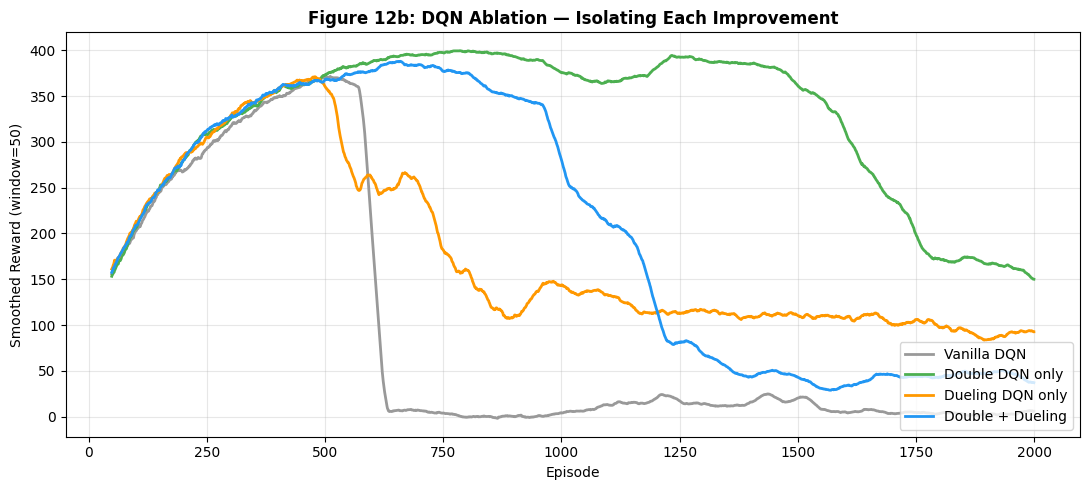

Figure 12b saved


In [18]:
# DQN Ablation: train all 4 combinations of Double and Dueling to see which improvement contributes what.
#   1. Vanilla DQN        - neither
#   2. Double DQN only
#   3. Dueling DQN only
#   4. Double + Dueling   - both (current)

dqn_episodes = 2000

class FlexibleDQN(nn.Module):
    """Vanilla or Dueling architecture controlled by use_dueling flag."""
    def __init__(self, input_dim=2, output_dim=3, use_dueling=True):
        super().__init__()
        self.use_dueling = use_dueling
        self.feature     = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU())
        if use_dueling:
            self.value = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1))
            self.adv   = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, output_dim))
        else:
            self.q     = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, output_dim))

    def forward(self, x):
        f = self.feature(x)
        if self.use_dueling:
            V = self.value(f)
            A = self.adv(f)
            return V + A - A.mean(dim=1, keepdim=True)
        else:
            return self.q(f)


class FlexibleDQNAgent:
    """DQN agent with toggleable Double and Dueling improvements."""
    def __init__(self, use_double=True, use_dueling=True,
                 state_dim=2, action_dim=3, lr=0.001, gamma=0.9,
                 epsilon=0.9, epsilon_decay=0.995, epsilon_min=0.01,
                 batch_size=64, target_update=50):
        self.use_double    = use_double
        self.action_dim    = action_dim
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.batch_size    = batch_size
        self.target_update = target_update
        self.steps         = 0
        self.online_net = FlexibleDQN(state_dim, action_dim, use_dueling=use_dueling)
        self.target_net = FlexibleDQN(state_dim, action_dim, use_dueling=use_dueling)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)
        self.memory    = ReplayMemory()

    def select_action(self, sv, holding):
        valid = [0,2] if holding==1 else [0,1]
        if random.random() < self.epsilon:
            return random.choice(valid)
        st = torch.FloatTensor(sv).unsqueeze(0)
        with torch.no_grad():
            q = self.online_net(st).squeeze()
        masked = torch.full((self.action_dim,), float('-inf'))
        for a in valid: masked[a] = q[a]
        return int(torch.argmax(masked).item())

    def store(self, *args):
        self.memory.push(*args)

    def train_step(self):
        if len(self.memory) < self.batch_size: return
        s, a, r, ns, d = zip(*self.memory.sample(self.batch_size))
        s  = torch.FloatTensor(s)
        a  = torch.LongTensor(a).unsqueeze(1)
        r  = torch.FloatTensor(r)
        ns = torch.FloatTensor(ns)
        d  = torch.FloatTensor(d)
        curr_q = self.online_net(s).gather(1, a).squeeze()
        with torch.no_grad():
            if self.use_double:
                # Double DQN: online net selects action, target net evaluates it
                best_a   = self.online_net(ns).argmax(dim=1, keepdim=True)
                target_q = self.target_net(ns).gather(1, best_a).squeeze()
            else:
                # Vanilla DQN: target net both selects AND evaluates (overestimation)
                target_q = self.target_net(ns).max(dim=1)[0]
            target_q = r + self.gamma * target_q * (1 - d)
        loss = nn.MSELoss()(curr_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# Run all 4 ablation configurations
ablation_configs = [
    ('Vanilla DQN',       False, False),
    ('Double DQN only',   True,  False),
    ('Dueling DQN only',  False, True),
    ('Double + Dueling',  True,  True),
]

ablation_results = {}
for name, use_double, use_dueling in ablation_configs:
    print(f'\nTraining {name} (Double={use_double}, Dueling={use_dueling})...')
    agent   = FlexibleDQNAgent(use_double=use_double, use_dueling=use_dueling)
    rewards, _, _ = run_dqn(agent, episode_data, dqn_episodes, verbose=False)
    ablation_results[name] = rewards
    safe = name.replace(' ', '_').replace('+', 'plus')
    np.save(os.path.join(SAVE_DIR, f'dqn_ablation_seeded{safe}.npy'), np.array(rewards))
    print(f'  last-100 avg: {np.mean(rewards[-100:]):.2f}')

# Comparison table
print('\n--- DQN Ablation Comparison ---')
print(f'{"Configuration":<22} {"First100":>10} {"Last100":>10} {"Peak":>10}')
print('-' * 56)
for name, rewards in ablation_results.items():
    first = np.mean(rewards[:100])
    last  = np.mean(rewards[-100:])
    peak  = np.max(rewards)
    print(f'{name:<22}  {first:>9.2f}  {last:>9.2f}  {peak:>9.2f}')

# Comparison figure
plt.figure(figsize=(11, 5))
colors = ['#999999', '#4CAF50', '#FF9800', '#2196F3']
for (name, rewards), c in zip(ablation_results.items(), colors):
    plt.plot(np.arange(49, len(rewards)), smooth(rewards, 50),
             label=name, color=c, linewidth=2)
plt.title('Figure 12b: DQN Ablation — Isolating Each Improvement',
          fontsize=12, fontweight='bold')
plt.xlabel('Episode')
plt.ylabel('Smoothed Reward (window=50)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig12b_dqn_ablation_seeded.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12b saved')


Training Vanilla DQN WITH FIXES (Double=False, Dueling=False)...

Best smoothed reward: 354.87 at episode 755
  last-100 avg: 15.91

Training Double DQN only WITH FIXES (Double=True, Dueling=False)...

Best smoothed reward: 401.93 at episode 1717
  last-100 avg: 399.13

Training Dueling DQN only WITH FIXES (Double=False, Dueling=True)...

Best smoothed reward: 371.82 at episode 1028
  last-100 avg: 48.57

Training Double + Dueling WITH FIXES (Double=True, Dueling=True)...

Best smoothed reward: 407.69 at episode 1935
  last-100 avg: 405.98

--- DQN Ablation Comparison (WITH FIXES) ---
Configuration            First100    Last100       Peak
--------------------------------------------------------
Vanilla DQN                167.17      15.91     385.64
Double DQN only            162.29     399.13     426.10
Dueling DQN only           157.37      48.57     406.47
Double + Dueling           158.54     405.98     431.37


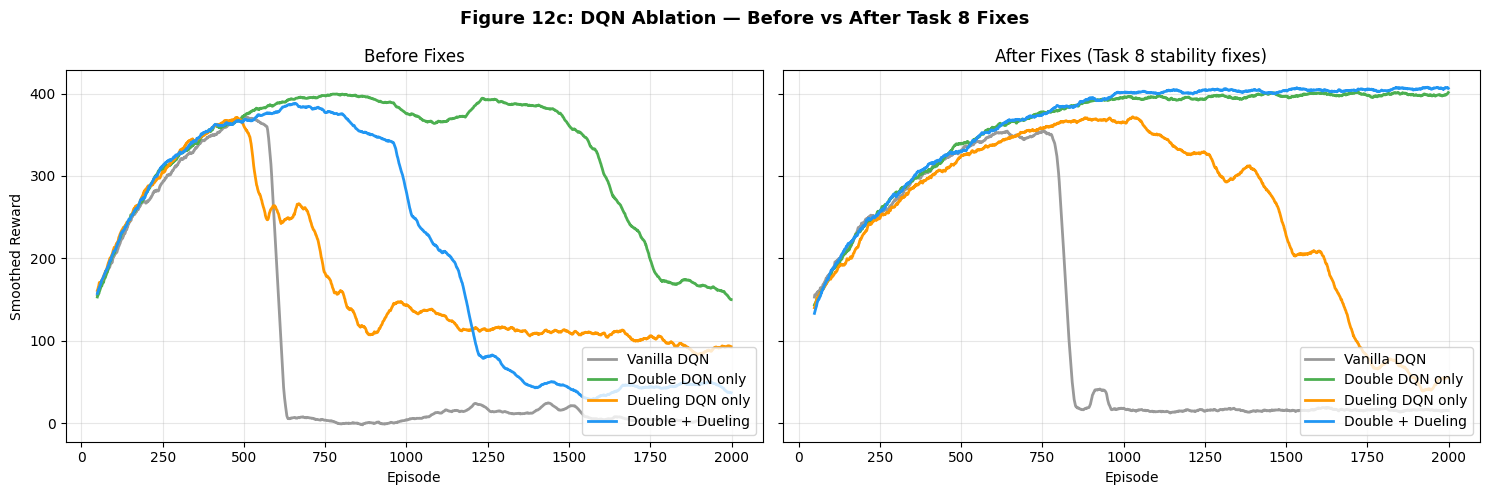

Figure 12c saved


In [19]:
# DQN Ablation v2 — same 4 configs WITH the Task 8 fixes applied.
# Fixes: action masking in targets, Huber loss, eps_min=0.05, 20k replay buffer, target_update=200. Demonstrates the combined Double + Dueling architecture becomes stable and best-performing once implementation-level issues are addressed.

# DQN Ablation v2: same 4 configs WITH the Task 8 fixes applied.
# Demonstrates the fixes make Double + Dueling stable and the best performer.

class FixedDQNAgent(FlexibleDQNAgent):
    """FlexibleDQNAgent with all Task 8 stability fixes applied."""
    def __init__(self, use_double=True, use_dueling=True,
                 state_dim=2, action_dim=3, lr=0.001, gamma=0.9,
                 epsilon=0.9, epsilon_decay=0.997,
                 epsilon_min=0.05,            # FIX 1: higher floor
                 batch_size=64,
                 target_update=200):          # FIX 2: slower updates
        super().__init__(use_double=use_double, use_dueling=use_dueling,
                         state_dim=state_dim, action_dim=action_dim,
                         lr=lr, gamma=gamma, epsilon=epsilon,
                         epsilon_decay=epsilon_decay, epsilon_min=epsilon_min,
                         batch_size=batch_size, target_update=target_update)
        self.memory = ReplayMemory(capacity=20000)   # FIX 3: larger buffer

    def train_step(self):
        if len(self.memory) < self.batch_size: return
        s, a, r, ns, d = zip(*self.memory.sample(self.batch_size))
        s  = torch.FloatTensor(s)
        a  = torch.LongTensor(a).unsqueeze(1)
        r  = torch.FloatTensor(r)
        ns = torch.FloatTensor(ns)
        d  = torch.FloatTensor(d)
        curr_q = self.online_net(s).gather(1, a).squeeze()

        with torch.no_grad():
            if self.use_double:
                # FIX 4: action masking in target Q-value selection
                online_q = self.online_net(ns)
                holding_next = ns[:, 1]
                mask = torch.full_like(online_q, float('-inf'))
                for i in range(len(ns)):
                    valid = [0, 2] if holding_next[i] == 1 else [0, 1]
                    for v in valid: mask[i, v] = online_q[i, v]
                best_a   = mask.argmax(dim=1, keepdim=True)
                target_q = self.target_net(ns).gather(1, best_a).squeeze()
            else:
                target_q = self.target_net(ns).max(dim=1)[0]
            target_q = r + self.gamma * target_q * (1 - d)

        loss = nn.SmoothL1Loss()(curr_q, target_q)   # FIX 5: Huber loss
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())


# Re-run all 4 configs WITH FIXES
ablation_results_fixed = {}
for name, use_double, use_dueling in ablation_configs:
    print(f'\nTraining {name} WITH FIXES (Double={use_double}, Dueling={use_dueling})...')
    agent   = FixedDQNAgent(use_double=use_double, use_dueling=use_dueling)
    rewards, _, _ = run_dqn(agent, episode_data, dqn_episodes, verbose=False)
    ablation_results_fixed[name] = rewards
    safe = name.replace(' ', '_').replace('+', 'plus')
    np.save(os.path.join(SAVE_DIR, f'dqn_ablation_fixed_seeded_{safe}.npy'), np.array(rewards))
    print(f'  last-100 avg: {np.mean(rewards[-100:]):.2f}')

# Comparison table (with fixes)
print('\n--- DQN Ablation Comparison (WITH FIXES) ---')
print(f'{"Configuration":<22} {"First100":>10} {"Last100":>10} {"Peak":>10}')
print('-' * 56)
for name, rewards in ablation_results_fixed.items():
    first = np.mean(rewards[:100])
    last  = np.mean(rewards[-100:])
    peak  = np.max(rewards)
    print(f'{name:<22}  {first:>9.2f}  {last:>9.2f}  {peak:>9.2f}')

# Side-by-side figure: pre-fix vs post-fix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
colors = ['#999999', '#4CAF50', '#FF9800', '#2196F3']
for (name, rewards), c in zip(ablation_results.items(), colors):
    ax1.plot(np.arange(49, len(rewards)), smooth(rewards, 50),
             label=name, color=c, linewidth=2)
ax1.set_title('Before Fixes', fontsize=12)
ax1.set_xlabel('Episode'); ax1.set_ylabel('Smoothed Reward')
ax1.legend(loc='lower right'); ax1.grid(True, alpha=0.3)

for (name, rewards), c in zip(ablation_results_fixed.items(), colors):
    ax2.plot(np.arange(49, len(rewards)), smooth(rewards, 50),
             label=name, color=c, linewidth=2)
ax2.set_title('After Fixes (Task 8 stability fixes)', fontsize=12)
ax2.set_xlabel('Episode')
ax2.legend(loc='lower right'); ax2.grid(True, alpha=0.3)

fig.suptitle('Figure 12c: DQN Ablation — Before vs After Task 8 Fixes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig12c_dqn_ablation_fixed_seeded.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12c saved')

# TASK 9: Proximal Policy Optimization (PPO) on MSFT Trading Environment
Following Lec07 algorithm: collect trajectories → compute advantages with GAE → optimise clipped objective → repeat.

Action masking applied: invalid actions (buy when holding, sell when not holding) are zeroed out in the policy distribution.

In [ ]:
# PPO hyperparameters (Lec07 standard values)
PPO_LR       = 3e-4   # learning rate
PPO_GAMMA    = 0.99   # discount factor
PPO_LAMBDA   = 0.95   # GAE lambda — Lec07: "usually λ≈0.95"
PPO_CLIP_EPS = 0.2    # clipping ε — Lec07: clip(r_t, 1-ε, 1+ε)
PPO_EPOCHS   = 4      # K epochs per update
PPO_BATCH    = 256    # minibatch size
PPO_ENT_COEF = 0.01   # entropy coefficient c_2 (Lec09 total loss)
PPO_VF_COEF  = 0.5    # value loss coefficient c_1
PPO_EPISODES = 2000   # training episodes
PPO_PATH     = os.path.join(SAVE_DIR, 'ppo_weights.pth')

class TradingActorCritic(nn.Module):
    """
    Two-headed network for PPO on the MSFT trading environment.
    Identical architecture to DQN's DuelingDQN trunk but different heads:
      - Actor head: outputs logits → π_θ(a|s) (stochastic policy, Lec07)
      - Critic head: outputs scalar V(s)       (state value, Lec07)
    Action masking is applied to logits before sampling — invalid actions
    get logit = -inf so their probability is exactly zero.
    """
    def __init__(self, state_dim=2, action_dim=3, hidden_dim=64):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_head  = nn.Linear(hidden_dim, action_dim)
        self.critic_head = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        f = self.trunk(state)
        return self.actor_head(f), self.critic_head(f).squeeze(-1)

    def _mask(self, logits, holding_val):
        """Zero out invalid actions for a single state."""
        mask = torch.full((3,), float('-inf'))
        valid = [0, 2] if holding_val == 1 else [0, 1]
        for a in valid: mask[a] = 0.0
        return logits + mask

    def get_action(self, sv, holding):
        """
        Sample an action at collection time.
        Returns (action, log_prob, value) — all needed for rollout buffer.
        log_prob is stored as π_θold for the PPO ratio later.
        """
        state_t       = torch.FloatTensor(sv)
        logits, value = self.forward(state_t)
        logits        = self._mask(logits, holding)
        dist          = Categorical(logits=logits)
        action        = dist.sample()
        log_prob      = dist.log_prob(action)
        return action.item(), log_prob.detach(), value.detach()

    def evaluate(self, states, actions):
        """
        Re-evaluate (state, action) pairs under the CURRENT policy.
        Called during PPO update to compute new log_probs for the ratio
        r_t(θ) = π_θ(a|s) / π_θold(a|s) = exp(new_log_prob - old_log_prob).
        Masks are reconstructed from states[:,1] (the holding feature).
        """
        logits, values = self.forward(states)
        # Reconstruct holding from state vector (holding is always states[:,1])
        holdings = states[:, 1].long()
        masks = torch.full_like(logits, float('-inf'))
        for i in range(len(holdings)):
            valid = [0, 2] if holdings[i].item() == 1 else [0, 1]
            for a in valid: masks[i, a] = 0.0
        logits     = logits + masks
        dist       = Categorical(logits=logits)
        log_probs  = dist.log_prob(actions)
        entropy    = dist.entropy()
        return log_probs, values, entropy

ppo_ac = TradingActorCritic()
print(f'TradingActorCritic defined')
print(f'Parameters: {sum(p.numel() for p in ppo_ac.parameters())}')

# Quick sanity check
sv_test = get_state_vector(0.5, 0)   # price up, not holding
a, lp, v = ppo_ac.get_action(sv_test, holding=0)
print(f'Sanity check — action: {a} (should be 0=HOLD or 1=BUY), log_prob: {lp:.3f}, V(s): {v:.3f}')

TradingActorCritic defined
Parameters: 4612
Sanity check — action: 1 (should be 0=HOLD or 1=BUY), log_prob: -0.523, V(s): -0.059


In [ ]:
def compute_gae(rewards, values, dones, gamma=PPO_GAMMA, lam=PPO_LAMBDA, last_value=0.0):
    """
    Generalized Advantage Estimation (Lec07: GAE).

    A_t^GAE = Σ_{l=0}^∞ (γλ)^l δ_{t+l}
    where  δ_t = r_t + γV(s_{t+1}) - V(s_t)   ← TD residual

    Computed backwards through the episode — each step reuses the
    previous gae value, making it O(T) instead of O(T²).
    """
    T          = len(rewards)
    advantages = torch.zeros(T)
    gae        = 0.0

    for t in reversed(range(T)):
        next_val = last_value if t == T - 1 else values[t + 1].item()
        # TD residual: how much better was reality vs what critic predicted?
        delta = rewards[t] + gamma * next_val * (1.0 - dones[t]) - values[t].item()
        # GAE recursion: A_t = δ_t + γλ(1-done) * A_{t+1}
        gae        = delta + gamma * lam * (1.0 - dones[t]) * gae
        advantages[t] = gae

    returns = advantages + values.detach()   # critic target = A_t + V(s_t)
    return advantages, returns


def ppo_update(ac, optimizer, states, actions, old_log_probs, advantages, returns):
    """
    PPO clipped objective update (Lec07: 'Optimise the Clipped Objective').

    Full loss (Lec09 total loss formula):
        L = L^CLIP  −  c1 * L_V  +  c2 * H(π_θ)
    where:
        L^CLIP  = E[min(r_t * A_t,  clip(r_t, 1-ε, 1+ε) * A_t)]
        L_V     = MSE(V(s), returns)
        H(π_θ)  = entropy bonus encouraging exploration
    """
    # Normalise advantages — zero mean, unit variance per batch
    # Reduces variance without changing which actions are relatively better
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    T = len(states)
    for _ in range(PPO_EPOCHS):
        idxs = torch.randperm(T)
        for start in range(0, T, PPO_BATCH):
            b   = idxs[start:start + PPO_BATCH]
            s   = states[b]
            a   = actions[b]
            olp = old_log_probs[b]
            adv = advantages[b]
            ret = returns[b]

            # Re-evaluate under current policy
            new_lp, vals, entropy = ac.evaluate(s, a)

            # Probability ratio r_t(θ) = π_θ(a|s) / π_θold(a|s)
            # Done in log space for numerical stability
            ratio = torch.exp(new_lp - olp)

            # Clipped surrogate objective L^CLIP (Lec07)
            surr1 = ratio * adv
            surr2 = torch.clamp(ratio, 1 - PPO_CLIP_EPS, 1 + PPO_CLIP_EPS) * adv
            actor_loss  = -torch.min(surr1, surr2).mean()

            # Critic loss: V(s) should match actual returns
            critic_loss  = nn.MSELoss()(vals, ret)

            # Entropy bonus: keeps policy from collapsing to deterministic
            entropy_loss = -entropy.mean()

            # Combined loss
            loss = actor_loss + PPO_VF_COEF * critic_loss + PPO_ENT_COEF * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ac.parameters(), max_norm=0.5)
            optimizer.step()


print('compute_gae and ppo_update defined')

compute_gae and ppo_update defined


In [ ]:
def run_ppo(data, n_episodes=PPO_EPISODES, verbose=True):
    """
    PPO training loop — implements Lec07's four-step algorithm:
      1. Collect trajectory using current policy π_θold
      2. Compute advantages with GAE
      3. Optimise clipped objective for K epochs
      4. Discard data, repeat with updated policy
    Key difference from DQN: no replay buffer. Each episode's data is
    used for K update epochs then thrown away — PPO is on-policy.
    """
    ac        = TradingActorCritic()
    optimizer = optim.Adam(ac.parameters(), lr=PPO_LR)

    rewards_history = []
    best_smoothed   = -np.inf
    best_episode    = -1

    if os.path.exists(PPO_PATH):
        os.remove(PPO_PATH)
    print(f'Training PPO on MSFT ({n_episodes} episodes) with checkpointing...')

    for ep in range(n_episodes):

        # ---- Step 1: Collect trajectory ----
        states_buf, actions_buf, log_probs_buf = [], [], []
        values_buf, rewards_buf, dones_buf     = [], [], []

        holding = random.randint(0, 1)
        total   = 0.0

        for t in range(len(data) - 1):
            pc    = float(data.loc[t, 'price_change'])
            sv    = get_state_vector(pc, holding)
            si    = get_state(pc, holding)

            action, log_prob, value = ac.get_action(sv, holding)

            reward = R[si, action]
            if np.isnan(reward): reward = 0.0
            total += reward

            if action == 1 and holding == 0: holding = 1
            elif action == 2 and holding == 1: holding = 0

            done = 1.0 if t == len(data) - 2 else 0.0

            states_buf.append(sv);    actions_buf.append(action)
            log_probs_buf.append(log_prob)
            values_buf.append(value); rewards_buf.append(reward)
            dones_buf.append(done)

        # ---- Convert to tensors ----
        states_t    = torch.FloatTensor(states_buf)
        actions_t   = torch.LongTensor(actions_buf)
        log_probs_t = torch.stack(log_probs_buf)
        values_t    = torch.stack(values_buf)
        rewards_t   = torch.FloatTensor(rewards_buf)
        dones_t     = torch.FloatTensor(dones_buf)

        # ---- Step 2: Compute advantages (GAE) ----
        advantages, returns = compute_gae(rewards_t, values_t, dones_t)

        # ---- Step 3: Optimise clipped objective ----
        ppo_update(ac, optimizer, states_t, actions_t,
                   log_probs_t.detach(), advantages, returns)

        # ---- Step 4: Log + checkpoint ----
        rewards_history.append(total)
        if len(rewards_history) >= 50:
            sm = float(np.mean(rewards_history[-50:]))
            if sm > best_smoothed:
                best_smoothed = sm
                best_episode  = ep
                torch.save(ac.state_dict(), PPO_PATH)
        else:
            sm = float(np.mean(rewards_history))

        if verbose and ep % 50 == 0:
            print(f'  Ep {ep:>4} | Reward: {total:>8.2f} | Smoothed-50: {sm:>7.2f}')

    print(f'\nBest smoothed reward: {best_smoothed:.2f} at episode {best_episode}')
    print(f'PPO training complete. Best weights saved to {PPO_PATH}')
    return rewards_history, best_smoothed, best_episode


# Train + save reward history
ppo_rewards, ppo_best_sm, ppo_best_ep = run_ppo(episode_data, n_episodes=PPO_EPISODES)
np.save(os.path.join(SAVE_DIR, 'ppo_rewards.npy'), np.array(ppo_rewards))
print('Reward history saved.')

Training PPO on MSFT (2000 episodes) with checkpointing...
  Ep    0 | Reward:   167.13 | Smoothed-50:  167.13
  Ep   50 | Reward:   237.90 | Smoothed-50:  155.21
  Ep  100 | Reward:   185.77 | Smoothed-50:  202.25
  Ep  150 | Reward:   204.22 | Smoothed-50:  210.28
  Ep  200 | Reward:   218.82 | Smoothed-50:  203.57
  Ep  250 | Reward:    94.03 | Smoothed-50:  159.57
  Ep  300 | Reward:   239.26 | Smoothed-50:  193.55
  Ep  350 | Reward:   176.48 | Smoothed-50:  199.90
  Ep  400 | Reward:   136.78 | Smoothed-50:  202.36
  Ep  450 | Reward:   155.42 | Smoothed-50:  199.81
  Ep  500 | Reward:   248.55 | Smoothed-50:  210.03
  Ep  550 | Reward:   212.77 | Smoothed-50:  202.47
  Ep  600 | Reward:   197.79 | Smoothed-50:  196.38
  Ep  650 | Reward:   204.29 | Smoothed-50:  204.04
  Ep  700 | Reward:   190.38 | Smoothed-50:  201.03
  Ep  750 | Reward:   234.09 | Smoothed-50:  212.95
  Ep  800 | Reward:   182.72 | Smoothed-50:  208.13
  Ep  850 | Reward:   182.72 | Smoothed-50:  205.57
  Ep 

# Custom PPO on CartPole-v1
Reuses compute_gae and ppo_update from cell 41 unchanged.

Validates the implementation is correct before comparing to SB3.

In [ ]:
# Custom PPO on CartPole-v1 — Timestep-based
CARTPOLE_CUSTOM_PATH = os.path.join(SAVE_DIR, 'ppo_cartpole_custom_rewards.npy')
CARTPOLE_PATH        = os.path.join(SAVE_DIR, 'ppo_cartpole_weights.pth')
N_STEPS              = 2048
N_UPDATES            = 145

class CartPoleActorCritic(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden_dim=64):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_head  = nn.Linear(hidden_dim, action_dim)
        self.critic_head = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        f = self.trunk(state)
        return self.actor_head(f), self.critic_head(f).squeeze(-1)

    def get_action(self, obs):
        state_t       = torch.FloatTensor(obs)
        logits, value = self.forward(state_t)
        dist          = Categorical(logits=logits)
        action        = dist.sample()
        log_prob      = dist.log_prob(action)
        return action.item(), log_prob.detach(), value.detach()

    def evaluate(self, states, actions):
        logits, values = self.forward(states)
        dist           = Categorical(logits=logits)
        return dist.log_prob(actions), values, dist.entropy()

    def get_value(self, obs):
        with torch.no_grad():
            _, value = self.forward(torch.FloatTensor(obs).unsqueeze(0))
        return value.item()


def run_ppo_cartpole(n_updates=N_UPDATES, n_steps=N_STEPS, verbose=True):
    env             = gym.make("CartPole-v1")
    ac              = CartPoleActorCritic()
    optimizer       = optim.Adam(ac.parameters(), lr=PPO_LR)
    episode_rewards = []
    current_ep_reward = 0.0
    best_smoothed   = -np.inf
    best_update     = -1
    obs, _          = env.reset()

    if os.path.exists(CARTPOLE_PATH):
        os.remove(CARTPOLE_PATH)
    print(f'Training custom PPO on CartPole-v1 (timestep-based)...')
    print(f'n_steps={n_steps}, n_updates={n_updates}, total≈{n_steps*n_updates} timesteps')
    print(f'Solved = smoothed-100 >= 475')

    for update in range(n_updates):
        s_buf, a_buf, lp_buf, v_buf, r_buf, d_buf = [], [], [], [], [], []
        last_episode_done = False

        for step in range(n_steps):
            action, log_prob, value                      = ac.get_action(obs)
            next_obs, reward, terminated, truncated, _  = env.step(action)
            done = terminated or truncated

            s_buf.append(obs);  a_buf.append(action)
            lp_buf.append(log_prob); v_buf.append(value)
            r_buf.append(float(reward))
            d_buf.append(1.0 if terminated else 0.0)

            current_ep_reward  += reward
            last_episode_done   = done

            if done:
                episode_rewards.append(current_ep_reward)
                current_ep_reward = 0.0
                obs, _ = env.reset()
            else:
                obs = next_obs

        last_value = 0.0 if last_episode_done else ac.get_value(obs)

        states_t    = torch.FloatTensor(np.array(s_buf))
        actions_t   = torch.LongTensor(a_buf)
        log_probs_t = torch.stack(lp_buf)
        values_t    = torch.stack(v_buf)
        rewards_t   = torch.FloatTensor(r_buf)
        dones_t     = torch.FloatTensor(d_buf)

        advantages, returns = compute_gae(rewards_t, values_t, dones_t,
                                          last_value=last_value)
        ppo_update(ac, optimizer, states_t, actions_t,
                   log_probs_t.detach(), advantages, returns)

        sm = float(np.mean(episode_rewards[-100:])) if len(episode_rewards) >= 100 else float(np.mean(episode_rewards)) if episode_rewards else 0.0
        if len(episode_rewards) >= 100 and sm > best_smoothed:
            best_smoothed = sm
            best_update   = update
            torch.save(ac.state_dict(), CARTPOLE_PATH)

        if verbose and update % 10 == 0:
            solved = ' ✓ SOLVED' if sm >= 475 else ''
            print(f'  Update {update:>4} | Episodes: {len(episode_rewards):>5} | Smoothed-100: {sm:>6.1f}{solved}')

    print(f'\nBest smoothed-100: {best_smoothed:.1f} at update {best_update}')
    if os.path.exists(CARTPOLE_PATH):
        ac.load_state_dict(torch.load(CARTPOLE_PATH))
    print(f'{"SOLVED ✓" if best_smoothed >= 475 else "Not solved"}')
    env.close()
    return episode_rewards, best_smoothed


# Override globals for CartPole
PPO_BATCH    = 64
PPO_EPOCHS   = 10
PPO_ENT_COEF = 0.05

cartpole_custom_rewards, cp_best_sm = run_ppo_cartpole()
np.save(CARTPOLE_CUSTOM_PATH, np.array(cartpole_custom_rewards))
print('Saved.')

# Restore MSFT PPO settings
PPO_BATCH    = 256
PPO_EPOCHS   = 4
PPO_ENT_COEF = 0.01

Training custom PPO on CartPole-v1 (timestep-based)...
n_steps=2048, n_updates=145, total≈296960 timesteps
Solved = smoothed-100 >= 475
  Update    0 | Episodes:    98 | Smoothed-100:   20.9
  Update   10 | Episodes:   495 | Smoothed-100:   87.9
  Update   20 | Episodes:   673 | Smoothed-100:   96.5
  Update   30 | Episodes:   846 | Smoothed-100:  143.6
  Update   40 | Episodes:   958 | Smoothed-100:  173.5
  Update   50 | Episodes:  1091 | Smoothed-100:  153.4
  Update   60 | Episodes:  1201 | Smoothed-100:  181.9
  Update   70 | Episodes:  1291 | Smoothed-100:  213.9
  Update   80 | Episodes:  1349 | Smoothed-100:  304.4
  Update   90 | Episodes:  1391 | Smoothed-100:  409.9
  Update  100 | Episodes:  1432 | Smoothed-100:  493.3 ✓ SOLVED
  Update  110 | Episodes:  1474 | Smoothed-100:  493.4 ✓ SOLVED
  Update  120 | Episodes:  1515 | Smoothed-100:  493.4 ✓ SOLVED
  Update  130 | Episodes:  1556 | Smoothed-100:  495.4 ✓ SOLVED
  Update  140 | Episodes:  1600 | Smoothed-100:  485.2 ✓ S

In [ ]:
# SB3 PPO benchmark on CartPole-v1
# Uses matching hyperparameters and architecture for fair comparison.

!pip install stable-baselines3 -q

from stable_baselines3 import PPO as SB3PPO
from stable_baselines3.common.monitor import Monitor

CARTPOLE_SB3_PATH = os.path.join(SAVE_DIR, 'ppo_cartpole_sb3_rewards.npy')
SB3_TIMESTEPS     = 300000   # ~600 episodes at 500 steps each

print('Training SB3 PPO on CartPole-v1...')
env_sb3 = Monitor(gym.make("CartPole-v1"))

model = SB3PPO(
    "MlpPolicy", env_sb3,
    learning_rate  = PPO_LR,
    gamma          = PPO_GAMMA,
    gae_lambda     = PPO_LAMBDA,
    clip_range     = PPO_CLIP_EPS,
    ent_coef       = PPO_ENT_COEF,
    vf_coef        = PPO_VF_COEF,
    n_epochs       = PPO_EPOCHS,
    policy_kwargs  = dict(net_arch=[64, 64]),  # match hidden_dim=64
    verbose        = 0
)
model.learn(total_timesteps=SB3_TIMESTEPS)

sb3_rewards = env_sb3.get_episode_rewards()
np.save(CARTPOLE_SB3_PATH, np.array(sb3_rewards))

print(f'Episodes: {len(sb3_rewards)}')
print(f'Final smoothed-100: {np.mean(sb3_rewards[-100:]):.1f}')
print(f'{"SOLVED ✓" if np.mean(sb3_rewards[-100:]) >= 475 else "Not solved"}')
env_sb3.close()
print('SB3 rewards saved.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 45.4 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Training SB3 PPO on CartPole-v1...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Episodes: 984
Final smoothed-100: 500.0
SOLVED ✓
SB3 rewards saved.


---
## Task 10 — PPO Analysis and Algorithm Comparison

Custom PPO implemented on MSFT trading environment and validated on CartPole-v1.
Compared against Q-learning (Tasks 1–6) and DQN (Tasks 7–8) on the same MSFT
environment. SB3 PPO used as benchmark on CartPole-v1 to validate implementation
correctness.

Key findings: Q-learning and DQN outperform PPO on the MSFT environment due to
on-policy sample inefficiency and the coarse 4-state reward signal. Custom PPO
matches SB3 PPO on CartPole-v1 once timestep-based rollout collection is adopted,
validating the implementation is algorithmically correct.

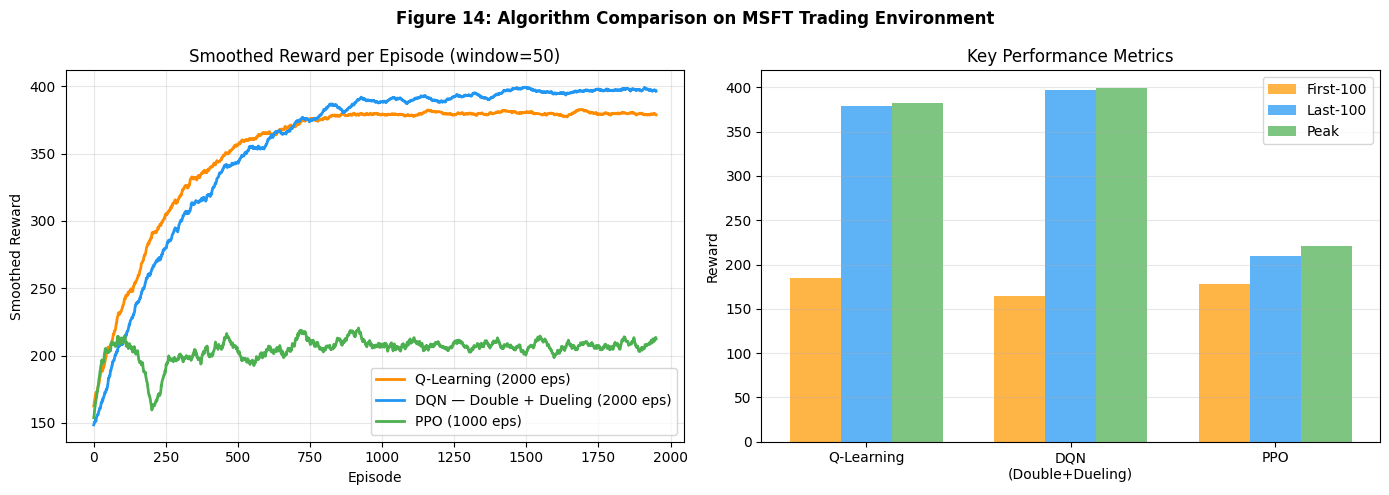

Figure 14 saved.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Figure 14: Task 10 — Three algorithm comparison on MSFT trading environment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 14: Algorithm Comparison on MSFT Trading Environment', fontweight='bold')

# Load reward histories
q_r   = np.load(os.path.join(SAVE_DIR, 'q_rewards.npy'))
dqn_r = np.load(os.path.join(SAVE_DIR, 'dqn_rewards_fixed.npy'))
ppo_r = np.load(os.path.join(SAVE_DIR, 'ppo_rewards.npy'))

def smooth(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# Left: Smoothed learning curves
ax1.plot(smooth(q_r),   color='#FF8C00', linewidth=2, label='Q-Learning (2000 eps)')
ax1.plot(smooth(dqn_r), color='#2196F3', linewidth=2, label='DQN — Double + Dueling (2000 eps)')
ax1.plot(smooth(ppo_r), color='#4CAF50', linewidth=2, label='PPO (2000 eps)')
ax1.set_title('Smoothed Reward per Episode (window=50)')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Smoothed Reward')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Key metrics bar chart
algorithms = ['Q-Learning', 'DQN\n(Double+Dueling)', 'PPO']
first_100  = [np.mean(q_r[:100]),   np.mean(dqn_r[:100]),   np.mean(ppo_r[:100])]
last_100   = [np.mean(q_r[-100:]),  np.mean(dqn_r[-100:]),  np.mean(ppo_r[-100:])]
peaks      = [max(smooth(q_r)),     max(smooth(dqn_r)),      max(smooth(ppo_r))]

x = np.arange(len(algorithms))
w = 0.25
ax2.bar(x - w, first_100, w, label='First-100', color='#FFA726', alpha=0.85)
ax2.bar(x,     last_100,  w, label='Last-100',  color='#42A5F5', alpha=0.85)
ax2.bar(x + w, peaks,     w, label='Peak',      color='#66BB6A', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(algorithms)
ax2.set_ylabel('Reward')
ax2.set_title('Key Performance Metrics')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig14_algorithm_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 14 saved.')

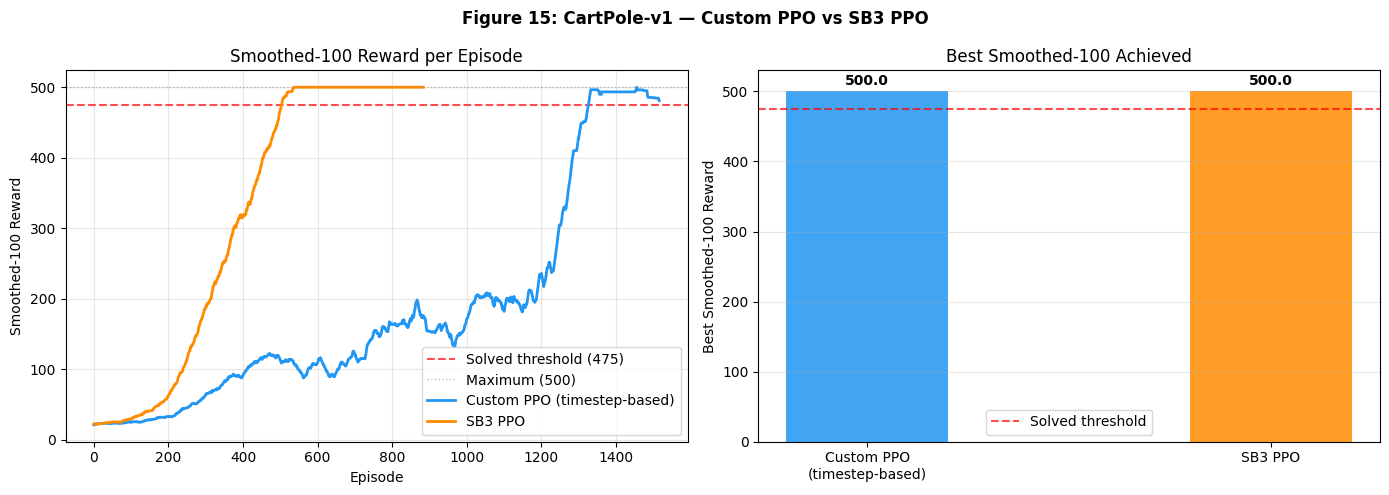

Figure 15 saved.


In [ ]:
# Figure 15: Task 10 — CartPole-v1 implementation validation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 15: CartPole-v1 — Custom PPO vs SB3 PPO', fontweight='bold')

cp_custom = np.load(os.path.join(SAVE_DIR, 'ppo_cartpole_custom_rewards.npy'))
cp_sb3    = np.load(os.path.join(SAVE_DIR, 'ppo_cartpole_sb3_rewards.npy'))

def smooth100(x):
    return np.convolve(x, np.ones(100)/100, mode='valid')

# Left: Smoothed-100 learning curves
ax1.axhline(y=475, color='red',  linestyle='--', alpha=0.7, linewidth=1.5, label='Solved threshold (475)')
ax1.axhline(y=500, color='gray', linestyle=':',  alpha=0.5, linewidth=1.0, label='Maximum (500)')
ax1.plot(smooth100(cp_custom), color='#2196F3', linewidth=2, label='Custom PPO (timestep-based)')
ax1.plot(smooth100(cp_sb3),    color='#FF8C00', linewidth=2, label='SB3 PPO')
ax1.set_title('Smoothed-100 Reward per Episode')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Smoothed-100 Reward')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Best smoothed-100 bar chart
labels   = ['Custom PPO\n(timestep-based)', 'SB3 PPO']
best_sms = [max(smooth100(cp_custom)), max(smooth100(cp_sb3))]
colors   = ['#2196F3', '#FF8C00']
bars = ax2.bar(labels, best_sms, color=colors, alpha=0.85, width=0.4)
ax2.axhline(y=475, color='red', linestyle='--', alpha=0.7, label='Solved threshold')
ax2.set_ylim(0, 530)
ax2.set_ylabel('Best Smoothed-100 Reward')
ax2.set_title('Best Smoothed-100 Achieved')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, best_sms):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fig15_cartpole_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 15 saved.')